# Exploración inicial del dataset de calidad del aire en México

Este notebook documenta la revisión exploratoria inicial de los datos usados en el proyecto final de Visualización Gráfica para IA.

El objetivo es revisar la estructura de los archivos, validar fechas, detectar valores faltantes, identificar valores extremos y conocer qué estaciones tienen información disponible antes de construir la aplicación interactiva en Shiny for Python.

In [14]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd().parent

RAW_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"

daily_path = RAW_DIR / "stations_daily.csv"
stations_path = RAW_DIR / "stations_rsinaica.csv"

daily = pd.read_csv(daily_path)
stations = pd.read_csv(stations_path)

In [9]:
print("stations_daily.csv")
display(daily.head())
print(daily.shape)
daily.info()

stations_daily.csv


,datetime,station_id,PM2.5,PM10,NOx,O3,CO,HR,NO,NO2,...,HCT,HRI,IUV,PB,PP,PST,RS,TMPI,UVA,XIL
0,2015-04-02,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.361000,NaN,NaN
1,2015-05-21,32,0.454967,0.347400,0.059194,0.029176,NaN,44.879091,0.029525,0.053121,...,NaN,NaN,NaN,570.775455,0.296364,NaN,7.871636,16.792818,NaN,NaN
2,2015-05-22,32,0.077821,0.389323,0.019158,0.051903,NaN,42.506000,0.009589,0.014215,...,NaN,NaN,NaN,558.360000,0.002750,NaN,384.788079,17.018949,NaN,NaN
3,2015-05-23,32,0.018036,0.387729,0.019711,0.021092,0.144603,54.734437,0.009863,0.013436,...,NaN,NaN,NaN,573.282187,0.038750,NaN,252.605975,18.575000,NaN,NaN
4,2015-05-24,32,0.024935,0.398042,0.024757,0.009568,0.494143,58.374574,0.012397,0.010337,...,NaN,NaN,NaN,572.169574,0.003404,NaN,259.231664,16.781064,NaN,NaN


(231592, 27)
<class 'pandas.DataFrame'>
RangeIndex: 231592 entries, 0 to 231591
Data columns (total 27 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   datetime    231592 non-null  str    
 1   station_id  231592 non-null  int64  
 2   PM2.5       161698 non-null  float64
 3   PM10        180481 non-null  float64
 4   NOx         112881 non-null  float64
 5   O3          192957 non-null  float64
 6   CO          175493 non-null  float64
 7   HR          123285 non-null  float64
 8   NO          118154 non-null  float64
 9   NO2         169286 non-null  float64
 10  TMP         127015 non-null  float64
 11  BEN         775 non-null     float64
 12  CH4         270 non-null     float64
 13  CN          595 non-null     float64
 14  CO2         56 non-null      float64
 15  H2S         280 non-null     float64
 16  HCNM        279 non-null     float64
 17  HCT         0 non-null       float64
 18  HRI         10205 non-null   float64
 19  

In [10]:
print("stations_rsinaica.csv")
display(stations.head())
print(stations.shape)
stations.info()

stations_rsinaica.csv


,station_id,station_name,station_code,network_id,network_name,network_code,street,ext,interior,colonia,...,date_validated2,passed_validation,video,lat,lon,date_started,timezone,street_view,video_interior,color
0,397,"CENICA 1, UAM Iztapalapa",CEN,144,NaN,ESTSP,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,19.489583,-98.801083,2002-01-01,"Tiempo del centro, UTC-6 (UTC-5 en verano)",NaN,NaN,Others
1,344,C. Salud Tlaxcoapán,TCP,127,NaN,TCP,NaN,NaN,NaN,NaN,...,NaN,NaN,Array,20.091472,-99.228417,NaN,"Tiempo del centro, UTC-6 (UTC-5 en verano)",NaN,NaN,Others
2,365,Costa Baja,UM,140,NaN,LAP,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2010-03-14,"Tiempo del centro, UTC-6 (UTC-5 en verano)",NaN,NaN,Others
3,393,Unidad Móvil de Hidalgo,UMHI,143,NaN,POP,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,19.489583,-98.801083,2013-05-24,"Tiempo del centro, UTC-6 (UTC-5 en verano)",NaN,NaN,Others
4,394,Unidad Móvil Iztapalapa,UMIZ,143,NaN,POP,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,19.489583,-98.801083,2013-05-21,"Tiempo del centro, UTC-6 (UTC-5 en verano)",NaN,NaN,Others


(341, 27)
<class 'pandas.DataFrame'>
RangeIndex: 341 entries, 0 to 340
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   station_id         341 non-null    int64  
 1   station_name       341 non-null    str    
 2   station_code       341 non-null    str    
 3   network_id         341 non-null    int64  
 4   network_name       334 non-null    str    
 5   network_code       340 non-null    str    
 6   street             187 non-null    str    
 7   ext                154 non-null    str    
 8   interior           74 non-null     str    
 9   colonia            186 non-null    str    
 10  zip                143 non-null    str    
 11  state_code         299 non-null    float64
 12  municipio_code     299 non-null    float64
 13  year_started       138 non-null    float64
 14  altitude           320 non-null    float64
 15  address            138 non-null    str    
 16  date_validated     20 non-n

El archivo daily contiene las mediciones por estación y fecha. El archivo rsinaica contiene la información geográfica y descriptiva necesaria para ubicar cada punto en el mapa.

In [11]:
print("Columnas de stations_daily:")
print(daily.columns.tolist())

print("\nColumnas de stations_rsinaica:")
print(stations.columns.tolist())

Columnas de stations_daily:
['datetime', 'station_id', 'PM2.5', 'PM10', 'NOx', 'O3', 'CO', 'HR', 'NO', 'NO2', 'TMP', 'BEN', 'CH4', 'CN', 'CO2', 'H2S', 'HCNM', 'HCT', 'HRI', 'IUV', 'PB', 'PP', 'PST', 'RS', 'TMPI', 'UVA', 'XIL']

Columnas de stations_rsinaica:
['station_id', 'station_name', 'station_code', 'network_id', 'network_name', 'network_code', 'street', 'ext', 'interior', 'colonia', 'zip', 'state_code', 'municipio_code', 'year_started', 'altitude', 'address', 'date_validated', 'date_validated2', 'passed_validation', 'video', 'lat', 'lon', 'date_started', 'timezone', 'street_view', 'video_interior', 'color']


In [12]:
daily["datetime"] = pd.to_datetime(daily["datetime"], errors="coerce", dayfirst=True)

print("Fechas inválidas:", daily["datetime"].isna().sum())
print("Fecha mínima:", daily["datetime"].min())
print("Fecha máxima:", daily["datetime"].max())

Fechas inválidas: 140261
Fecha mínima: 2000-01-01 00:00:00
Fecha máxima: 2021-12-12 00:00:00


In [13]:
daily["year"] = daily["datetime"].dt.year

year_counts = daily["year"].value_counts().sort_index()
display(year_counts)

year
2000.0      725
2001.0      732
2002.0      439
2006.0      162
2007.0       15
2008.0       18
2009.0       24
2010.0     4085
2011.0     4468
2012.0     5179
2013.0     5575
2014.0     6804
2015.0     6859
2016.0     7360
2017.0     9290
2018.0    10334
2019.0    10246
2020.0     9891
2021.0     9125
Name: count, dtype: int64

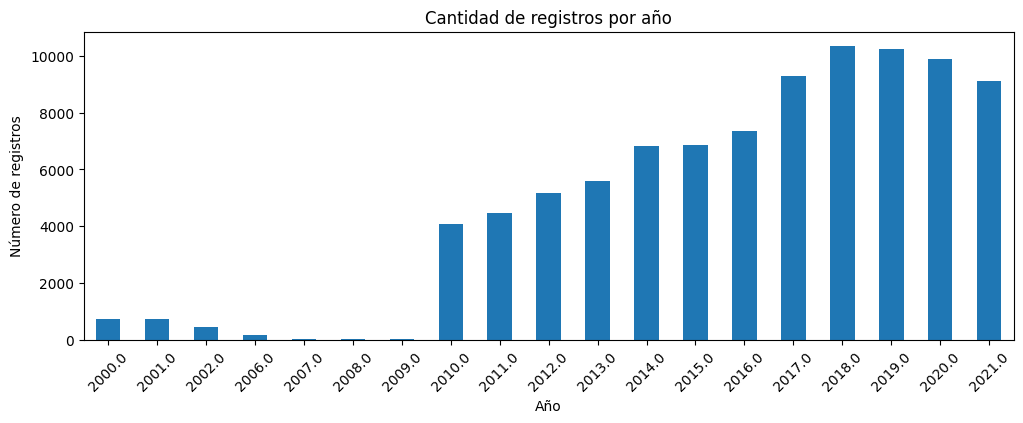

In [15]:
year_counts.plot(kind="bar", figsize=(12, 4))
plt.title("Cantidad de registros por año")
plt.xlabel("Año")
plt.ylabel("Número de registros")
plt.xticks(rotation=45)
plt.show()

Aunque la documentación general del dataset menciona el periodo 2010–2021, el archivo diario contiene registros desde el año 2000.

In [16]:
pollutants = ["PM2.5", "PM10", "O3", "NO2", "NOx", "CO"]
pollutants = [col for col in pollutants if col in daily.columns]

for col in pollutants:
    daily[col] = pd.to_numeric(daily[col], errors="coerce")

daily[pollutants].describe()

,PM2.5,PM10,O3,NO2,NOx,CO
count,1.616980e+05,1.804810e+05,192957.000000,1.692860e+05,1.128810e+05,175493.000000
mean,2.226160e+33,1.307211e+33,0.405834,1.896445e+01,2.853819e+01,5.589823
std,5.500417e+35,3.680391e+35,121.093397,7.752592e+03,9.493952e+03,336.347484
min,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000
25%,1.290000e+01,3.187417e+01,0.018483,9.441667e-03,1.415417e-02,0.531426
50%,1.960000e+01,4.738759e+01,0.025333,1.600592e-02,2.396125e-02,0.791667
75%,2.811156e+01,6.767537e+01,0.033375,2.477273e-02,3.937500e-02,1.202778
max,1.806160e+38,1.412893e+38,53185.473851,3.189756e+06,3.189756e+06,84087.353799


In [17]:
missing = daily[pollutants].isna().sum().sort_values(ascending=False)
missing_percent = (daily[pollutants].isna().mean() * 100).sort_values(ascending=False)

missing_table = pd.DataFrame({
    "faltantes": missing,
    "porcentaje": missing_percent
})

display(missing_table)

,faltantes,porcentaje
NOx,118711,51.258679
PM2.5,69894,30.179799
NO2,62306,26.903347
CO,56099,24.223203
PM10,51111,22.069415
O3,38635,16.682355


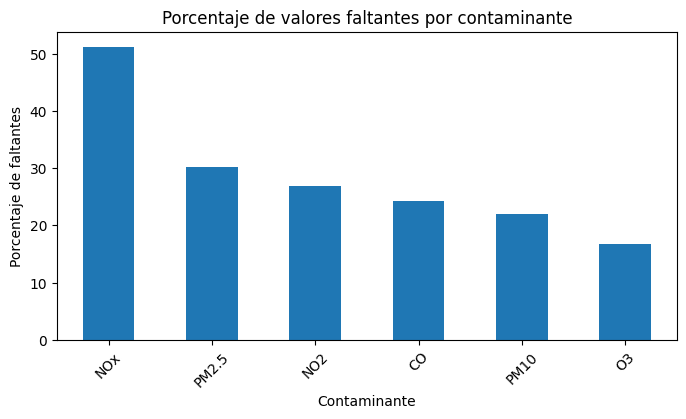

In [18]:
missing_percent.plot(kind="bar", figsize=(8, 4))
plt.title("Porcentaje de valores faltantes por contaminante")
plt.xlabel("Contaminante")
plt.ylabel("Porcentaje de faltantes")
plt.xticks(rotation=45)
plt.show()

In [19]:
for col in pollutants:
    print("\n", col)
    print(daily[col].describe(percentiles=[0.5, 0.9, 0.95, 0.99, 0.999]))


 PM2.5
count    1.616980e+05
mean     2.226160e+33
std      5.500417e+35
min      0.000000e+00
50%      1.960000e+01
90%      3.900000e+01
95%      4.995679e+01
99%      9.700000e+02
99.9%    9.970000e+02
max      1.806160e+38
Name: PM2.5, dtype: float64

 PM10
count    1.804810e+05
mean     1.307211e+33
std      3.680391e+35
min      0.000000e+00
50%      4.738759e+01
90%      9.308333e+01
95%      1.162500e+02
99%      9.700000e+02
99.9%    9.980345e+02
max      1.412893e+38
Name: PM10, dtype: float64

 O3
count    192957.000000
mean          0.405834
std         121.093397
min           0.000000
50%           0.025333
90%           0.042269
95%           0.048572
99%           0.072333
99.9%        32.435722
max       53185.473851
Name: O3, dtype: float64

 NO2
count    1.692860e+05
mean     1.896445e+01
std      7.752592e+03
min      0.000000e+00
50%      1.600592e-02
90%      3.391667e-02
95%      4.052418e-02
99%      6.162500e-02
99.9%    2.182268e+01
max      3.189756e+06
Name

Se detectaron valores extremadamente altos en algunos contaminantes. Estos valores distorsionan los promedios y las escalas de las visualizaciones. Por esta razón, en el script de limpieza se eliminaron valores negativos y valores superiores al percentil 99.9 de cada contaminante.

In [20]:
outlier_limits = {}

for col in pollutants:
    upper_limit = daily[col].quantile(0.999)
    outlier_limits[col] = upper_limit

outlier_limits_df = pd.DataFrame({
    "contaminante": outlier_limits.keys(),
    "percentil_99_9": outlier_limits.values()
})

display(outlier_limits_df)

,contaminante,percentil_99_9
0,PM2.5,997.000000
1,PM10,998.034517
2,O3,32.435722
3,NO2,21.822682
4,NOx,44.113447
5,CO,92.725649


In [21]:
for col in pollutants:
    upper_limit = daily[col].quantile(0.999)
    outliers = (daily[col] > upper_limit).sum()
    total = daily[col].notna().sum()
    print(f"{col}: {outliers} valores por encima del percentil 99.9 de {total} valores disponibles")

PM2.5: 122 valores por encima del percentil 99.9 de 161698 valores disponibles
PM10: 181 valores por encima del percentil 99.9 de 180481 valores disponibles
O3: 193 valores por encima del percentil 99.9 de 192957 valores disponibles
NO2: 170 valores por encima del percentil 99.9 de 169286 valores disponibles
NOx: 113 valores por encima del percentil 99.9 de 112881 valores disponibles
CO: 176 valores por encima del percentil 99.9 de 175493 valores disponibles


In [22]:
stations.columns = stations.columns.str.strip()
daily.columns = daily.columns.str.strip()

station_cols = [
    "station_id",
    "station_name",
    "station_code",
    "network_name",
    "state_code",
    "municipio_code",
    "lat",
    "lon"
]

stations_small = stations[station_cols].copy()

df = daily.merge(stations_small, on="station_id", how="left")

display(df.head())
print(df.shape)

,datetime,station_id,PM2.5,PM10,NOx,O3,CO,HR,NO,NO2,...,TMPI,UVA,XIL,station_name,station_code,network_name,state_code,municipio_code,lat,lon
0,2015-04-02,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,32.361000,NaN,NaN,Secretaría de Medio Ambiente,SMA,Aguascalientes,0.0,0.0,21.846392,-102.288431
1,2015-05-21,32,0.454967,0.347400,0.059194,0.029176,NaN,44.879091,0.029525,0.053121,...,16.792818,NaN,NaN,Secretaría de Medio Ambiente,SMA,Aguascalientes,0.0,0.0,21.846392,-102.288431
2,2015-05-22,32,0.077821,0.389323,0.019158,0.051903,NaN,42.506000,0.009589,0.014215,...,17.018949,NaN,NaN,Secretaría de Medio Ambiente,SMA,Aguascalientes,0.0,0.0,21.846392,-102.288431
3,2015-05-23,32,0.018036,0.387729,0.019711,0.021092,0.144603,54.734437,0.009863,0.013436,...,18.575000,NaN,NaN,Secretaría de Medio Ambiente,SMA,Aguascalientes,0.0,0.0,21.846392,-102.288431
4,2015-05-24,32,0.024935,0.398042,0.024757,0.009568,0.494143,58.374574,0.012397,0.010337,...,16.781064,NaN,NaN,Secretaría de Medio Ambiente,SMA,Aguascalientes,0.0,0.0,21.846392,-102.288431


(231592, 34)


In [23]:
stations_with_data = df["station_id"].nunique()
stations_catalog = stations["station_id"].nunique()

print("Estaciones en catálogo:", stations_catalog)
print("Estaciones con datos diarios:", stations_with_data)

Estaciones en catálogo: 341
Estaciones con datos diarios: 78


In [24]:
top_networks = (
    df.groupby("network_name")["station_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(15)
)

display(top_networks)

network_name
Valle de México    16
Monterrey          12
Toluca              4
Guadalajara         4
Puebla              3
Aguascalientes      2
Pachuca             2
León                2
Durango             2
Celaya              2
Irapuato            2
Morelia             2
Tepic               2
Salamanca           2
Oaxaca              2
Name: station_id, dtype: int64

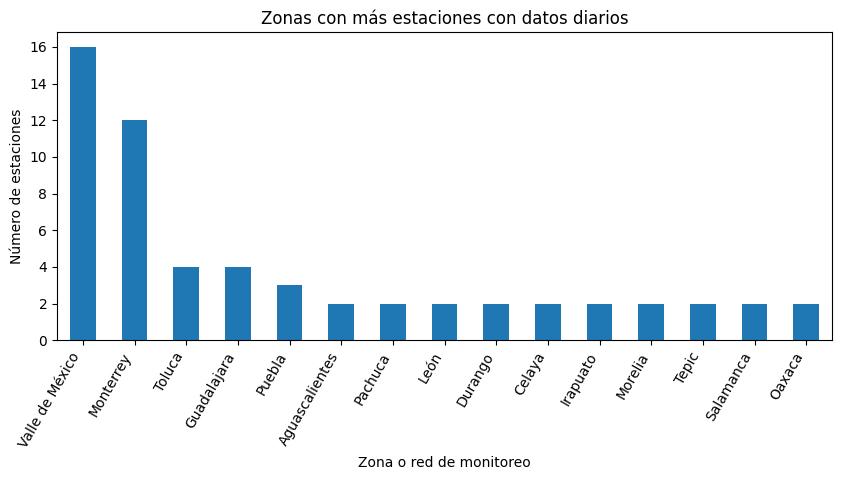

In [25]:
top_networks.plot(kind="bar", figsize=(10, 4))
plt.title("Zonas con más estaciones con datos diarios")
plt.xlabel("Zona o red de monitoreo")
plt.ylabel("Número de estaciones")
plt.xticks(rotation=60, ha="right")
plt.show()

In [26]:
leon_catalog = stations[
    stations["network_name"].astype(str).str.contains("León|Leon", case=False, na=False)
][["station_id", "station_name", "station_code", "network_name", "lat", "lon"]]

display(leon_catalog)

,station_id,station_name,station_code,network_name,lat,lon
98,74,CICEG - Bomberos,CC,León,21.103056,-101.636111
99,75,Facultad de Medicina,FM,León,21.133333,-101.680000
100,348,Zona Sur,LN-S,León,21.001222,-101.143722
101,76,T21,T21,León,21.108611,-101.688611
148,354,Dirección de Ecología Municipal,MOR,Moroleon,20.131944,-101.188333


In [27]:
leon_ids = leon_catalog["station_id"].tolist()

leon_daily_counts = (
    daily[daily["station_id"].isin(leon_ids)]
    .groupby("station_id")
    .size()
    .reset_index(name="registros_diarios")
)

leon_check = leon_catalog.merge(leon_daily_counts, on="station_id", how="left")
leon_check["registros_diarios"] = leon_check["registros_diarios"].fillna(0).astype(int)

display(leon_check)

,station_id,station_name,station_code,network_name,lat,lon,registros_diarios
0,74,CICEG - Bomberos,CC,León,21.103056,-101.636111,4368
1,75,Facultad de Medicina,FM,León,21.133333,-101.680000,3800
2,348,Zona Sur,LN-S,León,21.001222,-101.143722,0
3,76,T21,T21,León,21.108611,-101.688611,0
4,354,Dirección de Ecología Municipal,MOR,Moroleon,20.131944,-101.188333,0


Aunque el catálogo contiene varias estaciones asociadas a León, no todas tienen registros diarios en el archivo utilizado. Por eso, la aplicación muestra únicamente estaciones con datos disponibles.

In [28]:
map_stations = pd.read_csv(PROCESSED_DIR / "map_stations.csv")
monthly_pollution = pd.read_csv(PROCESSED_DIR / "monthly_pollution.csv")
weekday_pollution = pd.read_csv(PROCESSED_DIR / "weekday_pollution.csv")

print("map_stations:", map_stations.shape)
print("monthly_pollution:", monthly_pollution.shape)
print("weekday_pollution:", weekday_pollution.shape)

display(map_stations.head())

map_stations: (78, 13)
monthly_pollution: (9145, 13)
weekday_pollution: (546, 12)


,station_id,station_name,station_code,network_name,state_code,lat,lon,PM2.5,PM10,O3,NO2,NOx,CO
0,32,Secretaría de Medio Ambiente,SMA,Aguascalientes,0.0,21.846392,-102.288431,131.058837,87.653908,1.334104,1.404679,2.327863,0.858112
1,33,Centro,CEN,Aguascalientes,1.0,21.883781,-102.295825,96.115518,90.705393,4.029436,5.015165,7.399233,1.437958
2,53,SUR,SUR,Chihuahua,8.0,28.632775,-106.038867,23.730624,58.878269,0.028613,0.012102,0.021709,1.026845
3,56,CONALEP,CNP,Torreón,5.0,25.522694,-103.395806,19.746871,61.903549,0.020839,0.007743,0.031596,26.182600
4,59,IPN,IPN,Durango,10.0,24.051556,-104.611361,22.262307,71.465783,0.415023,0.019912,0.037838,2.191444


In [29]:
contaminante = "PM2.5"

top_pm25 = (
    map_stations[["station_name", "network_name", contaminante]]
    .dropna()
    .sort_values(contaminante, ascending=False)
    .head(10)
)

display(top_pm25)

,station_name,network_name,PM2.5
68,Jurisdicción Sanitaria,Monclova,283.780949
69,Centro de Rehabilitación DIF,Piedras Negras,235.015032
61,Universidad Veracruzana,Poza Rica,197.956158
15,Estación de Bomberos de Cd. Sahagún,Tepeapulco,131.673543
0,Secretaría de Medio Ambiente,Aguascalientes,131.058837
41,CEDART,Oaxaca,108.782795
67,Finanzas,Saltillo,104.188826
45,Palacio de Gobierno,Tlaxcala,98.520901
1,Centro,Aguascalientes,96.115518
16,Hospital,Huichapan,91.097659


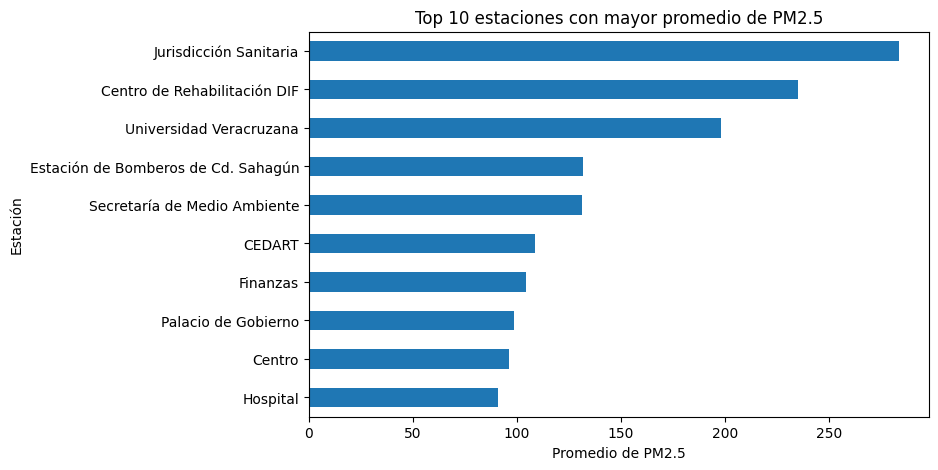

In [30]:
top_pm25.sort_values(contaminante).plot(
    kind="barh",
    x="station_name",
    y=contaminante,
    figsize=(8, 5),
    legend=False
)

plt.title(f"Top 10 estaciones con mayor promedio de {contaminante}")
plt.xlabel(f"Promedio de {contaminante}")
plt.ylabel("Estación")
plt.show()

## Conclusiones del EDA

1. El dataset contiene información útil para construir una narrativa visual sobre calidad del aire en México.
2. El archivo diario tiene registros desde el año 2000, aunque la descripción general del dataset menciona principalmente 2010–2021.
3. Existen valores extremos que deben limpiarse antes de calcular promedios o construir visualizaciones.
4. No todas las estaciones del catálogo tienen mediciones diarias disponibles.
5. Para la aplicación final se decidió trabajar con datos diarios y archivos procesados para mejorar el rendimiento.
6. Las visualizaciones principales se enfocan en ubicación, temporalidad mensual y diferencias por día de la semana.